In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

--- Detection Summary ---
status
Normal        950
Suspicious     50
Name: count, dtype: int64


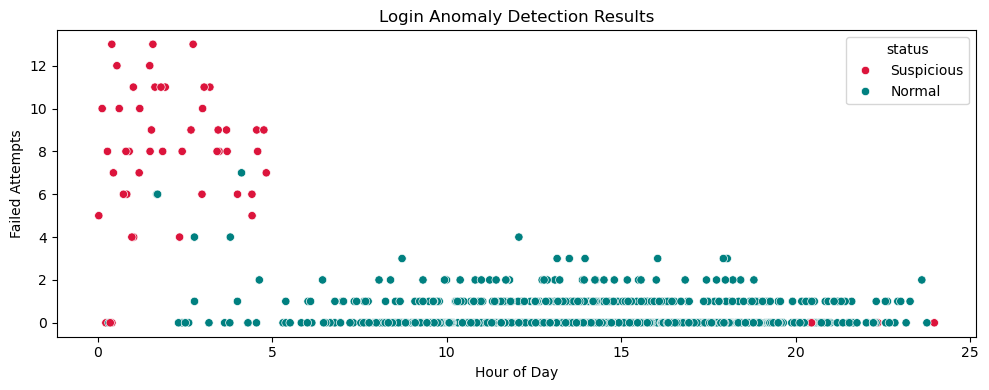

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_samples = 1000

normal_failed_attempts = np.random.poisson(lam=0.3, size=int(n_samples * 0.95))
normal_login_hour = np.random.normal(loc=14, scale=4, size=int(n_samples * 0.95)) % 24
normal_ip_count = np.random.poisson(lam=1.1, size=int(n_samples * 0.95))

anomaly_failed_attempts = np.random.poisson(lam=8, size=int(n_samples * 0.05))
anomaly_login_hour = np.random.uniform(low=0, high=5, size=int(n_samples * 0.05))
anomaly_ip_count = np.random.poisson(lam=4, size=int(n_samples * 0.05))

df = pd.DataFrame({
    'failed_attempts': np.concatenate([normal_failed_attempts, anomaly_failed_attempts]),
    'login_hour': np.concatenate([normal_login_hour, anomaly_login_hour]),
    'distinct_ip_count': np.concatenate([normal_ip_count, anomaly_ip_count])
}).sample(frac=1).reset_index(drop=True)

features = ['failed_attempts', 'login_hour', 'distinct_ip_count']
X_scaled = StandardScaler().fit_transform(df[features])

model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = model.fit_predict(X_scaled)
df['status'] = df['anomaly_score'].map({1: 'Normal', -1: 'Suspicious'})

print("--- Detection Summary ---")
print(df['status'].value_counts())

plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=df, 
    x='login_hour', 
    y='failed_attempts', 
    hue='status', 
    palette={'Normal': 'teal', 'Suspicious': 'crimson'}
)
plt.title('Login Anomaly Detection Results')
plt.xlabel('Hour of Day')
plt.ylabel('Failed Attempts')
plt.tight_layout()
plt.show()